#1 Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#2 Upload customer_cltv.csv

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_cltv.csv to customer_cltv.csv


#3 Load the dataset

In [3]:
df = pd.read_csv("customer_cltv.csv")
display(df.head())

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,FirstPurchase,LastPurchase,Country,Region,AcquisitionChannel,SubscriptionPlan,AverageOrderValue,CustomerLifespanDays,CustomerLifespanMonths,PurchaseFrequencyPerMonth,HistoricalCLTV,CLTVDifference,CLTVSegment,CLTVSegmentSort
0,C00001,2048.2195,2,7,2026-01-01,2026-01-05,India,East,Organic Search,Basic,1024.11,4,1.00,2.00,2048.22,0.00,Low Value,1
1,C00002,3127.6170,4,7,2026-02-06,2026-03-26,United Kingdom,North,Referral,Basic,781.90,48,1.58,2.53,3125.57,-2.05,Medium Value,2
2,C00003,22259.3860,7,22,2025-05-19,2025-09-23,United Kingdom,North,Social Media,Standard,3179.91,127,4.17,1.68,22277.18,17.79,Very High Value,4
3,C00004,10300.8000,1,5,2025-08-06,2025-08-06,India,Central,Organic Search,Premium,10300.80,0,1.00,1.00,10300.80,0.00,High Value,3
4,C00005,900.2240,1,4,2025-03-30,2025-03-30,India,East,Email,Basic,900.22,0,1.00,1.00,900.22,-0.00,Low Value,1


#4 Validate required columns

In [4]:
required_columns = [
    "CustomerID",
    "Region",
    "AcquisitionChannel",
    "SubscriptionPlan",
    "TotalRevenue",
    "TotalOrders",
    "AverageOrderValue",
    "CustomerLifespanMonths",
    "PurchaseFrequencyPerMonth",
    "HistoricalCLTV",
    "CLTVSegment"
]

missing = [
    col for col in required_columns
    if col not in df.columns
]

if missing:
    raise ValueError(
        f"Missing required columns: {missing}"
    )

print("Validation passed.")

Validation passed.


#5 Set correct CLTV segment order

In [5]:
segment_order = [
    "Low Value",
    "Medium Value",
    "High Value",
    "Very High Value"
]

df["CLTVSegment"] = pd.Categorical(
    df["CLTVSegment"],
    categories=segment_order,
    ordered=True
)

#6 Create segment sort number

In [6]:
if "CLTVSegmentSort" not in df.columns:

    sort_map = {
        "Low Value": 1,
        "Medium Value": 2,
        "High Value": 3,
        "Very High Value": 4
    }

    df["CLTVSegmentSort"] = (
        df["CLTVSegment"]
        .astype(str)
        .map(sort_map)
    )

#7 Check number of customers per segment

In [7]:
segment_counts = (
    df.groupby(
        "CLTVSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

display(segment_counts)

,CLTVSegment,Customers
0,Low Value,290
1,Medium Value,289
2,High Value,289
3,Very High Value,289


#8 Calculate customer share %

In [8]:
total_customers = segment_counts["Customers"].sum()

segment_counts["CustomerSharePercent"] = (
    segment_counts["Customers"]
    / total_customers
    * 100
).round(2)

display(segment_counts)

,CLTVSegment,Customers,CustomerSharePercent
0,Low Value,290,25.06
1,Medium Value,289,24.98
2,High Value,289,24.98
3,Very High Value,289,24.98


#9 Calculate CLTV contribution by segment

In [9]:
segment_value = (
    df.groupby(
        "CLTVSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalHistoricalCLTV=("HistoricalCLTV", "sum"),
        AverageHistoricalCLTV=("HistoricalCLTV", "mean")
    )
    .reset_index()
)

In [10]:
total_cltv = segment_value["TotalHistoricalCLTV"].sum()

segment_value["CLTVContributionPercent"] = (
    segment_value["TotalHistoricalCLTV"]
    / total_cltv
    * 100
).round(2)

In [11]:
segment_value["AverageHistoricalCLTV"] = (
    segment_value["AverageHistoricalCLTV"]
    .round(2)
)

segment_value["TotalHistoricalCLTV"] = (
    segment_value["TotalHistoricalCLTV"]
    .round(2)
)

display(segment_value)

,CLTVSegment,Customers,TotalHistoricalCLTV,AverageHistoricalCLTV,CLTVContributionPercent
0,Low Value,290,352732.27,1216.32,2.75
1,Medium Value,289,984930.22,3408.06,7.67
2,High Value,289,2232997.04,7726.63,17.39
3,Very High Value,289,9266927.19,32065.49,72.19


#10 Calculate revenue contribution

In [12]:
segment_revenue = (
    df.groupby(
        "CLTVSegment",
        observed=False
    )
    .agg(
        TotalRevenue=("TotalRevenue", "sum"),
        AverageRevenue=("TotalRevenue", "mean")
    )
    .reset_index()
)

In [13]:
total_revenue = (
    segment_revenue["TotalRevenue"].sum()
)

segment_revenue["RevenueContributionPercent"] = (
    segment_revenue["TotalRevenue"]
    / total_revenue
    * 100
).round(2)

display(segment_revenue)

,CLTVSegment,TotalRevenue,AverageRevenue,RevenueContributionPercent
0,Low Value,3.527387e+05,1216.340395,2.75
1,Medium Value,9.850684e+05,3408.541348,7.67
2,High Value,2.233277e+06,7727.600784,17.39
3,Very High Value,9.268407e+06,32070.610739,72.19


#11 Create Segment Profile

In [14]:
segment_profile = (
    df.groupby(
        "CLTVSegment",
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        TotalRevenue=("TotalRevenue", "sum"),
        AverageCLTV=("HistoricalCLTV", "mean"),
        MedianCLTV=("HistoricalCLTV", "median"),
        AverageOrders=("TotalOrders", "mean"),
        AverageOrderValue=("AverageOrderValue", "mean"),
        AverageLifespanMonths=("CustomerLifespanMonths", "mean"),
        AveragePurchaseFrequency=("PurchaseFrequencyPerMonth", "mean")
    )
    .reset_index()
)

In [15]:
round_columns = [
    "TotalRevenue",
    "AverageCLTV",
    "MedianCLTV",
    "AverageOrders",
    "AverageOrderValue",
    "AverageLifespanMonths",
    "AveragePurchaseFrequency"
]

segment_profile[round_columns] = (
    segment_profile[round_columns]
    .round(2)
)

display(segment_profile)

,CLTVSegment,Customers,TotalRevenue,AverageCLTV,MedianCLTV,AverageOrders,AverageOrderValue,AverageLifespanMonths,AveragePurchaseFrequency
0,Low Value,290,352738.71,1216.32,1225.39,1.36,962.17,1.08,1.24
1,Medium Value,289,985068.45,3408.06,3378.23,2.24,1843.43,1.31,1.73
2,High Value,289,2233276.63,7726.63,7568.04,3.39,3210.88,1.97,1.81
3,Very High Value,289,9268406.50,32065.49,24272.48,5.75,6344.76,3.47,1.86


#12 Customer count chart

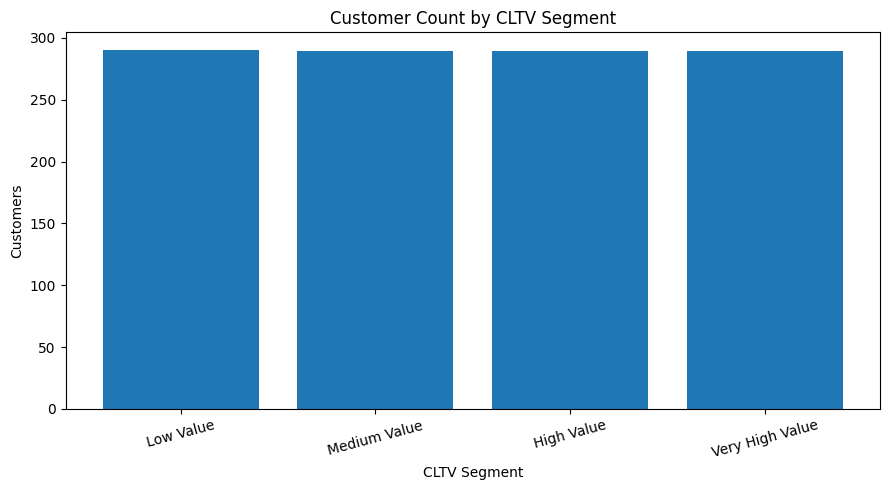

In [16]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_counts["CLTVSegment"].astype(str),
    segment_counts["Customers"]
)

plt.title("Customer Count by CLTV Segment")
plt.xlabel("CLTV Segment")
plt.ylabel("Customers")
plt.xticks(rotation=15)
plt.tight_layout()

plt.show()

#13 Save customer count chart

In [17]:
plt.savefig(
    "customer_count_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#14 CLTV contribution chart

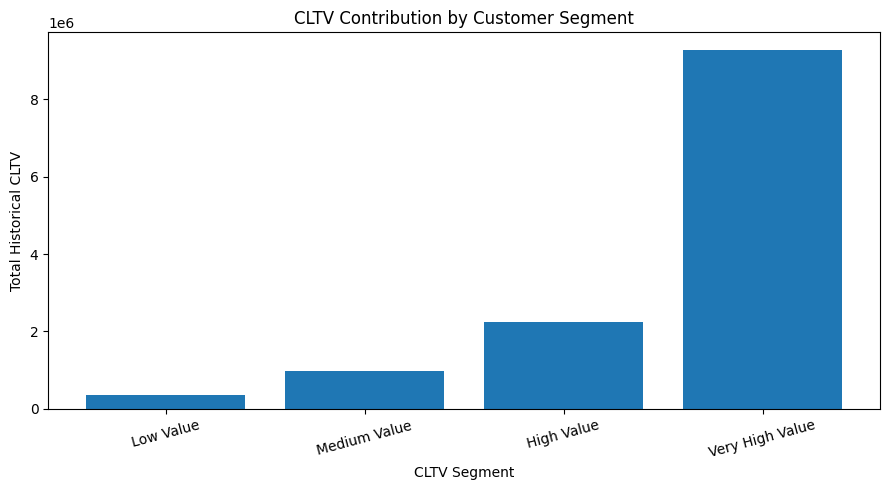

In [18]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_value["CLTVSegment"].astype(str),
    segment_value["TotalHistoricalCLTV"]
)

plt.title(
    "CLTV Contribution by Customer Segment"
)

plt.xlabel("CLTV Segment")
plt.ylabel("Total Historical CLTV")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

#15 Acquisition Channel × Segment

In [19]:
channel_segment = (
    df.groupby(
        [
            "AcquisitionChannel",
            "CLTVSegment"
        ],
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

display(channel_segment.head(20))

,AcquisitionChannel,CLTVSegment,Customers
0,Affiliate,Low Value,32
1,Affiliate,Medium Value,31
2,Affiliate,High Value,26
3,Affiliate,Very High Value,34
4,Email,Low Value,49
5,Email,Medium Value,34
6,Email,High Value,51
7,Email,Very High Value,41
8,Organic Search,Low Value,51
9,Organic Search,Medium Value,63


#16 Calculate % within each channel

In [20]:
channel_totals = (
    channel_segment
    .groupby("AcquisitionChannel")["Customers"]
    .transform("sum")
)

channel_segment["ShareWithinChannelPercent"] = (
    channel_segment["Customers"]
    / channel_totals
    * 100
).round(2)

display(channel_segment)

,AcquisitionChannel,CLTVSegment,Customers,ShareWithinChannelPercent
0,Affiliate,Low Value,32,26.02
1,Affiliate,Medium Value,31,25.20
2,Affiliate,High Value,26,21.14
3,Affiliate,Very High Value,34,27.64
4,Email,Low Value,49,28.00
5,Email,Medium Value,34,19.43
6,Email,High Value,51,29.14
7,Email,Very High Value,41,23.43
8,Organic Search,Low Value,51,19.25
9,Organic Search,Medium Value,63,23.77


#17 Create Acquisition Channel pivot

In [21]:
channel_segment_pivot = (
    channel_segment.pivot(
        index="AcquisitionChannel",
        columns="CLTVSegment",
        values="Customers"
    )
    .fillna(0)
)

display(channel_segment_pivot)

CLTVSegment,Low Value,Medium Value,High Value,Very High Value
AcquisitionChannel,,,,
Affiliate,32,31,26,34
Email,49,34,51,41
Organic Search,51,63,68,83
Paid Search,66,57,44,37
Referral,37,55,52,63
Social Media,55,49,48,31


#18 Region × Segment analysis

In [22]:
region_segment = (
    df.groupby(
        [
            "Region",
            "CLTVSegment"
        ],
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

In [23]:
region_totals = (
    region_segment
    .groupby("Region")["Customers"]
    .transform("sum")
)

region_segment["ShareWithinRegionPercent"] = (
    region_segment["Customers"]
    / region_totals
    * 100
).round(2)

display(region_segment.head(20))

,Region,CLTVSegment,Customers,ShareWithinRegionPercent
0,Central,Low Value,46,20.26
1,Central,Medium Value,63,27.75
2,Central,High Value,60,26.43
3,Central,Very High Value,58,25.55
4,East,Low Value,64,28.57
5,East,Medium Value,47,20.98
6,East,High Value,60,26.79
7,East,Very High Value,53,23.66
8,North,Low Value,60,25.86
9,North,Medium Value,63,27.16


#19 Subscription Plan × Segment

In [24]:
plan_segment = (
    df.groupby(
        [
            "SubscriptionPlan",
            "CLTVSegment"
        ],
        observed=False
    )
    .agg(
        Customers=("CustomerID", "nunique"),
        AverageCLTV=("HistoricalCLTV", "mean"),
        TotalCLTV=("HistoricalCLTV", "sum")
    )
    .reset_index()
)

In [25]:
plan_segment["AverageCLTV"] = (
    plan_segment["AverageCLTV"]
    .round(2)
)

plan_segment["TotalCLTV"] = (
    plan_segment["TotalCLTV"]
    .round(2)
)

display(plan_segment)

,SubscriptionPlan,CLTVSegment,Customers,AverageCLTV,TotalCLTV
0,Basic,Low Value,246,1181.75,290710.82
1,Basic,Medium Value,206,3380.10,696299.60
2,Basic,High Value,108,6869.71,741928.56
3,Basic,Very High Value,9,16198.70,145788.27
4,Premium,Low Value,6,1873.20,11239.23
5,Premium,Medium Value,7,3206.38,22444.68
6,Premium,High Value,42,8839.01,371238.59
7,Premium,Very High Value,151,41782.77,6309198.36
8,Standard,Low Value,38,1336.37,50782.22
9,Standard,Medium Value,76,3502.45,266185.94


#20 Find highest-value segment

In [26]:
highest_value_segment = (
    segment_value
    .sort_values(
        "TotalHistoricalCLTV",
        ascending=False
    )
    .iloc[0]
)

print(
    "Highest-value segment:",
    highest_value_segment["CLTVSegment"]
)

print(
    "Customers:",
    int(highest_value_segment["Customers"])
)

print(
    "Total Historical CLTV:",
    round(
        highest_value_segment[
            "TotalHistoricalCLTV"
        ],
        2
    )
)

print(
    "CLTV contribution (%):",
    round(
        highest_value_segment[
            "CLTVContributionPercent"
        ],
        2
    )
)

Highest-value segment: Very High Value
Customers: 289
Total Historical CLTV: 9266927.19
CLTV contribution (%): 72.19


#21 Compare behaviour across segments

In [27]:
behaviour_comparison = (
    segment_profile[
        [
            "CLTVSegment",
            "Customers",
            "AverageCLTV",
            "AverageOrders",
            "AverageOrderValue",
            "AverageLifespanMonths",
            "AveragePurchaseFrequency"
        ]
    ]
)

display(behaviour_comparison)

,CLTVSegment,Customers,AverageCLTV,AverageOrders,AverageOrderValue,AverageLifespanMonths,AveragePurchaseFrequency
0,Low Value,290,1216.32,1.36,962.17,1.08,1.24
1,Medium Value,289,3408.06,2.24,1843.43,1.31,1.73
2,High Value,289,7726.63,3.39,3210.88,1.97,1.81
3,Very High Value,289,32065.49,5.75,6344.76,3.47,1.86


#22 Export segment files

In [28]:
segment_counts.to_csv(
    "segment_customer_counts.csv",
    index=False
)

segment_value.to_csv(
    "segment_cltv_contribution.csv",
    index=False
)

segment_revenue.to_csv(
    "segment_revenue_contribution.csv",
    index=False
)

segment_profile.to_csv(
    "segment_profile.csv",
    index=False
)

channel_segment.to_csv(
    "channel_segment_mix.csv",
    index=False
)

region_segment.to_csv(
    "region_segment_mix.csv",
    index=False
)

plan_segment.to_csv(
    "subscription_plan_segment_mix.csv",
    index=False
)

#23 Download files

In [29]:
from google.colab import files

files.download(
    "segment_customer_counts.csv"
)

files.download(
    "segment_cltv_contribution.csv"
)

files.download(
    "segment_profile.csv"
)

files.download(
    "channel_segment_mix.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>